In [3]:
import sys
from pathlib import Path

root_dir = Path().absolute()

if root_dir.parts[-1:] == ('airquality',):
    root_dir = Path(*root_dir.parts[:-1])

if root_dir.parts[-1:] == ('notebooks',):
    root_dir = Path(*root_dir.parts[:-1])

root_dir = str(root_dir) 
print(f"Root dir: {root_dir}")

if root_dir not in sys.path:
    sys.path.append(root_dir)
    print(f"Added the following directory to the PYTHONPATH: {root_dir}")

from mlfs import config

settings = config.HopsworksSettings(_env_file=f"{root_dir}/.env")

Root dir: c:\Users\johan\dev\id2223-lab1
Added the following directory to the PYTHONPATH: c:\Users\johan\dev\id2223-lab1
HopsworksSettings initialized!


In [151]:
import os
from mlfs.airquality import util
import hopsworks
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error, r2_score
from datetime import datetime, timedelta

In [133]:
project = hopsworks.login(engine="python")
AQICN_API_KEY = settings.AQICN_API_KEY.get_secret_value() 
aqicn_url = "https://api.waqi.info/feed/@13983"
country = "Sweden"
city = "Stockholm"
street = "Sollentuna Ekmans Väg 11"
#latitude, longitude = util.get_city_coordinates(city)
latitude = "59.314017450051836"
longitude = "18.075630285191593"
secrets = hopsworks.get_secrets_api()
secret = secrets.get_secret("AQICN_API_KEY")
if secret is not None:
    secret.delete()
    print("Replacing existing AQICN_API_KEY")

secrets.create_secret("AQICN_API_KEY", AQICN_API_KEY)
today = datetime.today()

try:
    aq_today_df = util.get_pm25(aqicn_url, country, city, street, today, AQICN_API_KEY)
except hopsworks.RestAPIError:
    print("It looks like the AQICN_API_KEY doesn't work for your sensor. Is the API key correct? Is the sensor URL correct?")

aq_today_df.head()

2025-11-19 00:49:07,920 INFO: Closing external client and cleaning up certificates.
Connection closed.
2025-11-19 00:49:07,926 INFO: Initializing external client
2025-11-19 00:49:07,927 INFO: Base URL: https://c.app.hopsworks.ai:443
2025-11-19 00:49:08,610 WARNING: UserWarning: The installed hopsworks client version 4.4.2 may not be compatible with the connected Hopsworks backend version 4.2.2. 
To ensure compatibility please install the latest bug fix release matching the minor version of your backend (4.2) by running 'pip install hopsworks==4.2.*'



2025-11-19 00:49:09,586 INFO: Python Engine initialized.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1300628
Replacing existing AQICN_API_KEY
Secret created successfully, explore it at https://c.app.hopsworks.ai:443/account/secrets


,pm25,country,city,street,date,url
0,23.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,2025-11-19 00:49:11.151673,https://api.waqi.info/feed/@13983


Fetch the feature groups

In [134]:
fs = project.get_feature_store()
air_quality_fg = fs.get_feature_group(
    name='air_quality',
    version=1,
)
weather_fg = fs.get_feature_group(
    name='weather',
    version=1,
)
air_quality_fg

Read air quality features into a Pandas DataFrame

In [135]:
df_aq_lag = air_quality_fg.read()
df_aq_lag

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.91s) 


,date,pm25,country,city,street,url
0,2025-11-03 00:00:00+00:00,17.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
1,2024-01-08 00:00:00+00:00,17.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
2,2025-08-26 00:00:00+00:00,7.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
3,2023-03-10 00:00:00+00:00,18.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
4,2023-12-05 00:00:00+00:00,23.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
...,...,...,...,...,...,...
1134,2024-04-07 00:00:00+00:00,17.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
1135,2023-11-12 00:00:00+00:00,11.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
1136,2022-12-23 00:00:00+00:00,12.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
1137,2025-11-14 00:00:00+00:00,13.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983


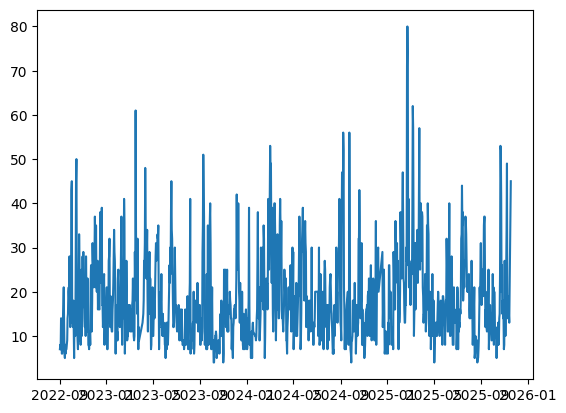

,date,pm25,country,city,street,url
0,2022-09-02 00:00:00+00:00,7.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
1,2022-09-03 00:00:00+00:00,8.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
2,2022-09-04 00:00:00+00:00,7.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
3,2022-09-05 00:00:00+00:00,14.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
4,2022-09-06 00:00:00+00:00,12.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
...,...,...,...,...,...,...
1169,2025-11-14 00:00:00+00:00,13.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
1170,2025-11-15 00:00:00+00:00,21.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
1171,2025-11-16 00:00:00+00:00,29.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983
1172,2025-11-17 00:00:00+00:00,37.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983


In [136]:
# Sort and interpolate missing dates.
df_aq_lag = df_aq_lag.set_index("date").sort_index()
full_idx = pd.date_range(
    start=df_aq_lag.index.min(),
    end=df_aq_lag.index.max(),
    freq="D"
)
df_aq_lag = df_aq_lag.reindex(full_idx)
df_aq_lag.index.name = "date"
df_aq_lag["pm25"] = df_aq_lag["pm25"].interpolate(method="time")
df_aq_lag = df_aq_lag.reset_index()

# Add supplementary info
df_aq_lag['country']=country
df_aq_lag['city']=city
df_aq_lag['street']=street
df_aq_lag['url']=aqicn_url

plt.plot(df_aq_lag["date"], df_aq_lag["pm25"])
plt.show()
df_aq_lag

Add features for previous 1-3 days pm25 readings

In [137]:
for k in [1, 2, 3]:
    df_aq_lag[f"pm25_lag{k}"] = df_aq_lag["pm25"].shift(k)

df_aq_lag.dropna(inplace=True)
df_aq_lag.info()
df_aq_lag

<class 'pandas.core.frame.DataFrame'>
Index: 1171 entries, 3 to 1173
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype                  
---  ------     --------------  -----                  
 0   date       1171 non-null   datetime64[ns, Etc/UTC]
 1   pm25       1171 non-null   float32                
 2   country    1171 non-null   object                 
 3   city       1171 non-null   object                 
 4   street     1171 non-null   object                 
 5   url        1171 non-null   object                 
 6   pm25_lag1  1171 non-null   float32                
 7   pm25_lag2  1171 non-null   float32                
 8   pm25_lag3  1171 non-null   float32                
dtypes: datetime64[ns, Etc/UTC](1), float32(4), object(4)
memory usage: 73.2+ KB


,date,pm25,country,city,street,url,pm25_lag1,pm25_lag2,pm25_lag3
3,2022-09-05 00:00:00+00:00,14.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,7.0,8.0,7.0
4,2022-09-06 00:00:00+00:00,12.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,14.0,7.0,8.0
5,2022-09-07 00:00:00+00:00,6.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,12.0,14.0,7.0
6,2022-09-08 00:00:00+00:00,6.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,6.0,12.0,14.0
7,2022-09-09 00:00:00+00:00,7.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,6.0,6.0,12.0
...,...,...,...,...,...,...,...,...,...
1169,2025-11-14 00:00:00+00:00,13.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,15.0,17.0,19.0
1170,2025-11-15 00:00:00+00:00,21.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,13.0,15.0,17.0
1171,2025-11-16 00:00:00+00:00,29.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,21.0,13.0,15.0
1172,2025-11-17 00:00:00+00:00,37.0,Sweden,Stockholm,Sollentuna Ekmans Väg 11,https://api.waqi.info/feed/@13983,29.0,21.0,13.0


Add data expectation

In [138]:
import great_expectations as ge

aq_expectation_suite = ge.core.ExpectationSuite(
    expectation_suite_name="aq_expectation_suite"
)

aq_expectation_suite.add_expectation(
    ge.core.ExpectationConfiguration(
        expectation_type="expect_column_min_to_be_between",
        kwargs={
            "column":"pm25",
            "min_value":-0.1,
            "max_value":500.0,
            "strict_min":True
        }
    )
)

{"expectation_type": "expect_column_min_to_be_between", "kwargs": {"column": "pm25", "min_value": -0.1, "max_value": 500.0, "strict_min": true}, "meta": {}}

Create a new feature group to store lagged air quality dataframe.

In [139]:
aq_lag_fg = fs.get_or_create_feature_group(
    name='aq_lag',
    description='Lagged air quality for the previous 1-3 days',
    version=1,
    primary_key=['country','city', 'street'],
    event_time="date",
    expectation_suite=aq_expectation_suite
)
aq_lag_fg.insert(df_aq_lag)
aq_lag_fg.update_feature_description("date", "Date of measurement of air quality")
aq_lag_fg.update_feature_description("country", "Country where the air quality was measured (sometimes a city in acqcn.org)")
aq_lag_fg.update_feature_description("city", "City where the air quality was measured")
aq_lag_fg.update_feature_description("street", "Street in the city where the air quality was measured")
aq_lag_fg.update_feature_description("pm25", "Particles less than 2.5 micrometers in diameter (fine particles) pose health risk")
aq_lag_fg.update_feature_description("pm25_lag1", "PM25 reading 1 day prior")
aq_lag_fg.update_feature_description("pm25_lag2", "PM25 reading 2 days prior")
aq_lag_fg.update_feature_description("pm25_lag3", "PM25 reading 3 days prior")

Feature Group created successfully, explore it at 
https://c.app.hopsworks.ai:443/p/1300628/fs/1288259/fg/1719078
2025-11-19 00:49:51,846 INFO: 	1 expectation(s) included in expectation_suite.
Validation succeeded.
Validation Report saved successfully, explore a summary at https://c.app.hopsworks.ai:443/p/1300628/fs/1288259/fg/1719078


Uploading Dataframe: 100.00% |██████████| Rows 1171/1171 | Elapsed Time: 00:01 | Remaining Time: 00:00


Launching job: aq_lag_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://c.app.hopsworks.ai:443/p/1300628/jobs/named/aq_lag_1_offline_fg_materialization/executions


Now, that we've added a new features, we can load our model and retrain it on the new features.

Create a new feature view to train on.

In [143]:
# Select features for training data.
selected_features = aq_lag_fg.select(['pm25', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'date']).join(weather_fg.select_features(), on=['city'])
feature_view = fs.get_or_create_feature_view(
    name='aq_lag_fv',
    description="weather and lagged 1-3 day air quality features with air quality as the target",
    version=1,
    labels=['pm25'],
    query=selected_features,
)

2025-11-19 00:52:27,138 INFO: Using ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'wind_direction_10m_dominant'] from feature group `weather` as features for the query. To include primary key and event time use `select_all`.
Feature view created successfully, explore it at 
https://c.app.hopsworks.ai:443/p/1300628/fs/1288259/fv/aq_lag_fv/version/1


In [145]:
start_date_test_data = "2025-05-01"
# Convert string to datetime object
test_start = datetime.strptime(start_date_test_data, "%Y-%m-%d")
X_train, X_test, y_train, y_test = feature_view.train_test_split(
    test_start=test_start
)
X_features = X_train.drop(columns=['date'])
X_test_features = X_test.drop(columns=['date'])

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.34s) 
2025-11-19 00:54:36,604 WARNING: VersionWarning: Incremented version to `2`.

2025-11-19 00:54:36,615 INFO: Provenance cached data - overwriting last accessed/created training dataset from 1 to 2.


In [149]:
X_train

,pm25_lag1,pm25_lag2,pm25_lag3,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_direction_10m_dominant
0,7.0,8.0,7.0,2022-09-05 00:00:00+00:00,10.364417,0.0,11.631956,320.399994
1,14.0,7.0,8.0,2022-09-06 00:00:00+00:00,12.941501,0.0,17.935081,271.074097
2,12.0,14.0,7.0,2022-09-07 00:00:00+00:00,11.274834,0.2,11.753877,34.392643
3,6.0,12.0,14.0,2022-09-08 00:00:00+00:00,11.058167,0.6,10.594036,81.069511
4,6.0,6.0,12.0,2022-09-09 00:00:00+00:00,12.806084,0.0,21.479664,111.331238
...,...,...,...,...,...,...,...,...
964,11.0,7.0,18.0,2025-04-26 00:00:00+00:00,4.939417,0.0,13.752048,326.839844
965,10.0,11.0,7.0,2025-04-27 00:00:00+00:00,8.479001,0.0,18.083506,211.242142
966,13.0,10.0,11.0,2025-04-28 00:00:00+00:00,11.935249,0.1,25.084663,258.606140
967,24.0,13.0,10.0,2025-04-29 00:00:00+00:00,11.904000,0.0,20.170443,301.991791


In [147]:
y_train

,pm25
0,14.0
1,12.0
2,6.0
3,6.0
4,7.0
...,...
964,10.0
965,13.0
966,24.0
967,10.0


In [150]:
# Creating an instance of the XGBoost Regressor
xgb_regressor = XGBRegressor()

# Fitting the XGBoost Regressor to the training data
xgb_regressor.fit(X_features, y_train)

# Predicting target values on the test set
y_pred = xgb_regressor.predict(X_test_features)

# Calculating Mean Squared Error (MSE) using sklearn
mse = mean_squared_error(y_test.iloc[:,0], y_pred)
print("MSE:", mse)

# Calculating R squared using sklearn
r2 = r2_score(y_test.iloc[:,0], y_pred)
print("R squared:", r2)

df = y_test
df['predicted_pm25'] = y_pred
df['date'] = X_test['date']
df = df.sort_values(by=['date'])
df.head(5)

2025-11-19 00:58:15,772 WARNING: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

2025-11-19 00:58:15,773 WARNING: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

MSE: 59.13847
2025-11-19 00:58:15,778 WARNING: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

2025-11-19 00:58:15,781 WARNING: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

R squared: 0.3053620835667916


,pm25,predicted_pm25,date
969,18.0,16.343927,2025-05-01 00:00:00+00:00
970,17.0,19.876045,2025-05-02 00:00:00+00:00
971,4.0,14.506824,2025-05-03 00:00:00+00:00
972,8.0,10.058806,2025-05-04 00:00:00+00:00
973,10.0,5.266422,2025-05-05 00:00:00+00:00


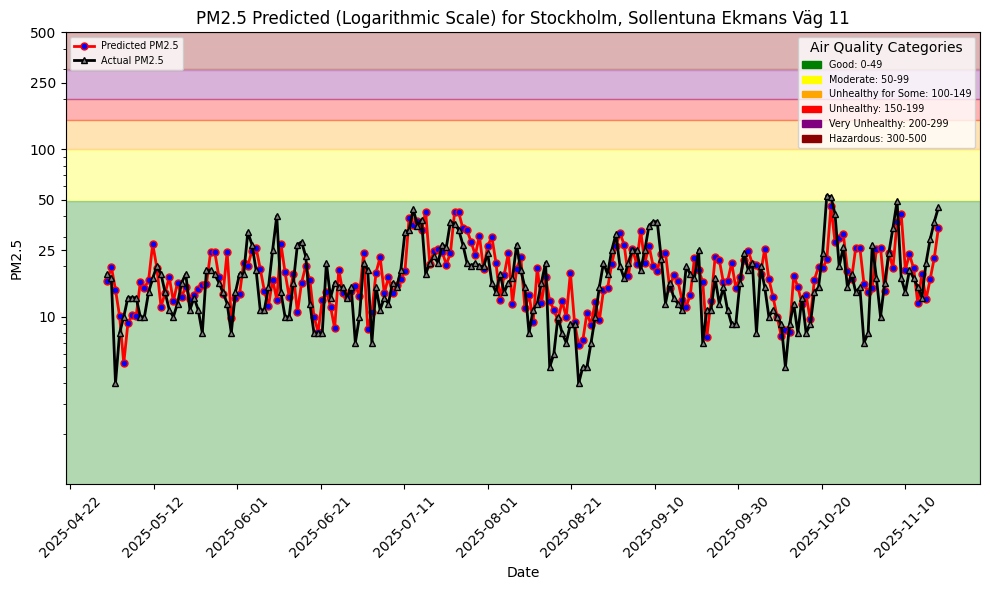

In [158]:
# Creating a directory for the model artifacts if it doesn't exist
model_dir = "air_quality_model"

if not os.path.exists(model_dir):
    os.mkdir(model_dir)

images_dir = model_dir + "/images"

if not os.path.exists(images_dir):
    os.mkdir(images_dir)

model_path = model_dir + "/new_model.json"
xgb_regressor.save_model(model_path)
file_path = images_dir + "/new_pm25_hindcast.png"
plt = util.plot_air_quality_forecast(city, street, df, file_path, hindcast=True) 
plt.show()
res_dict = { 
        "MSE": str(mse),
        "R squared": str(r2),
    }

In [160]:
mr = project.get_model_registry()

# Creating a Python model in the model registry named 'new_air_quality_xgboost_model'

aq_model = mr.python.create_model(
    name="air_quality_xgboost_model", 
    metrics= res_dict,
    feature_view=feature_view,
    description="Air Quality (PM2.5) predictor",
)

# Saving the model artifacts to the 'air_quality_model' directory in the model registry
aq_model.save(model_path)

  0%|          | 0/6 [00:00<?, ?it/s]

Uploading c:\Users\johan\dev\id2223-lab1\notebooks\airquality\air_quality_model/new_model.json: 0.000%|       …

Uploading c:\Users\johan\dev\id2223-lab1\notebooks\airquality\model_schema.json: 0.000%|          | 0/827 elap…

Model created, explore it at https://c.app.hopsworks.ai:443/p/1300628/models/air_quality_xgboost_model/2


Model(name: 'air_quality_xgboost_model', version: 2)